步骤1/6: 加载所有数据和模型...
测试集最大径流量样本索引: 173, 流量值: 7760.0
成功加载LSTM模型: ./models/lstm/lstm_best_model.pth
测试集最大径流量样本ANN预测值: 6205.150763244985
测试集最大径流量样本LSTM预测值: 6732.91259765625
步骤2/6: 计算LR和XGB的特征重要性...
正在计算XGB的特征重要性...
步骤3/6: 加载或计算ANN的SHAP值...
加载已保存的SHAP结果: combined_analysis_results\ann_shap_results.pkl
步骤4/6: 加载或计算LSTM的SHAP值...
加载已保存的SHAP结果: combined_analysis_results\lstm_shap_results.pkl
步骤5/6: 分析SHAP特征重要性...
步骤6/6: 生成3x2组合分析图表...


G:\Anaconda\envs\torch\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


3x2组合分析图表已保存至: combined_analysis_results\plots\3x2_combined_feature_analysis.png


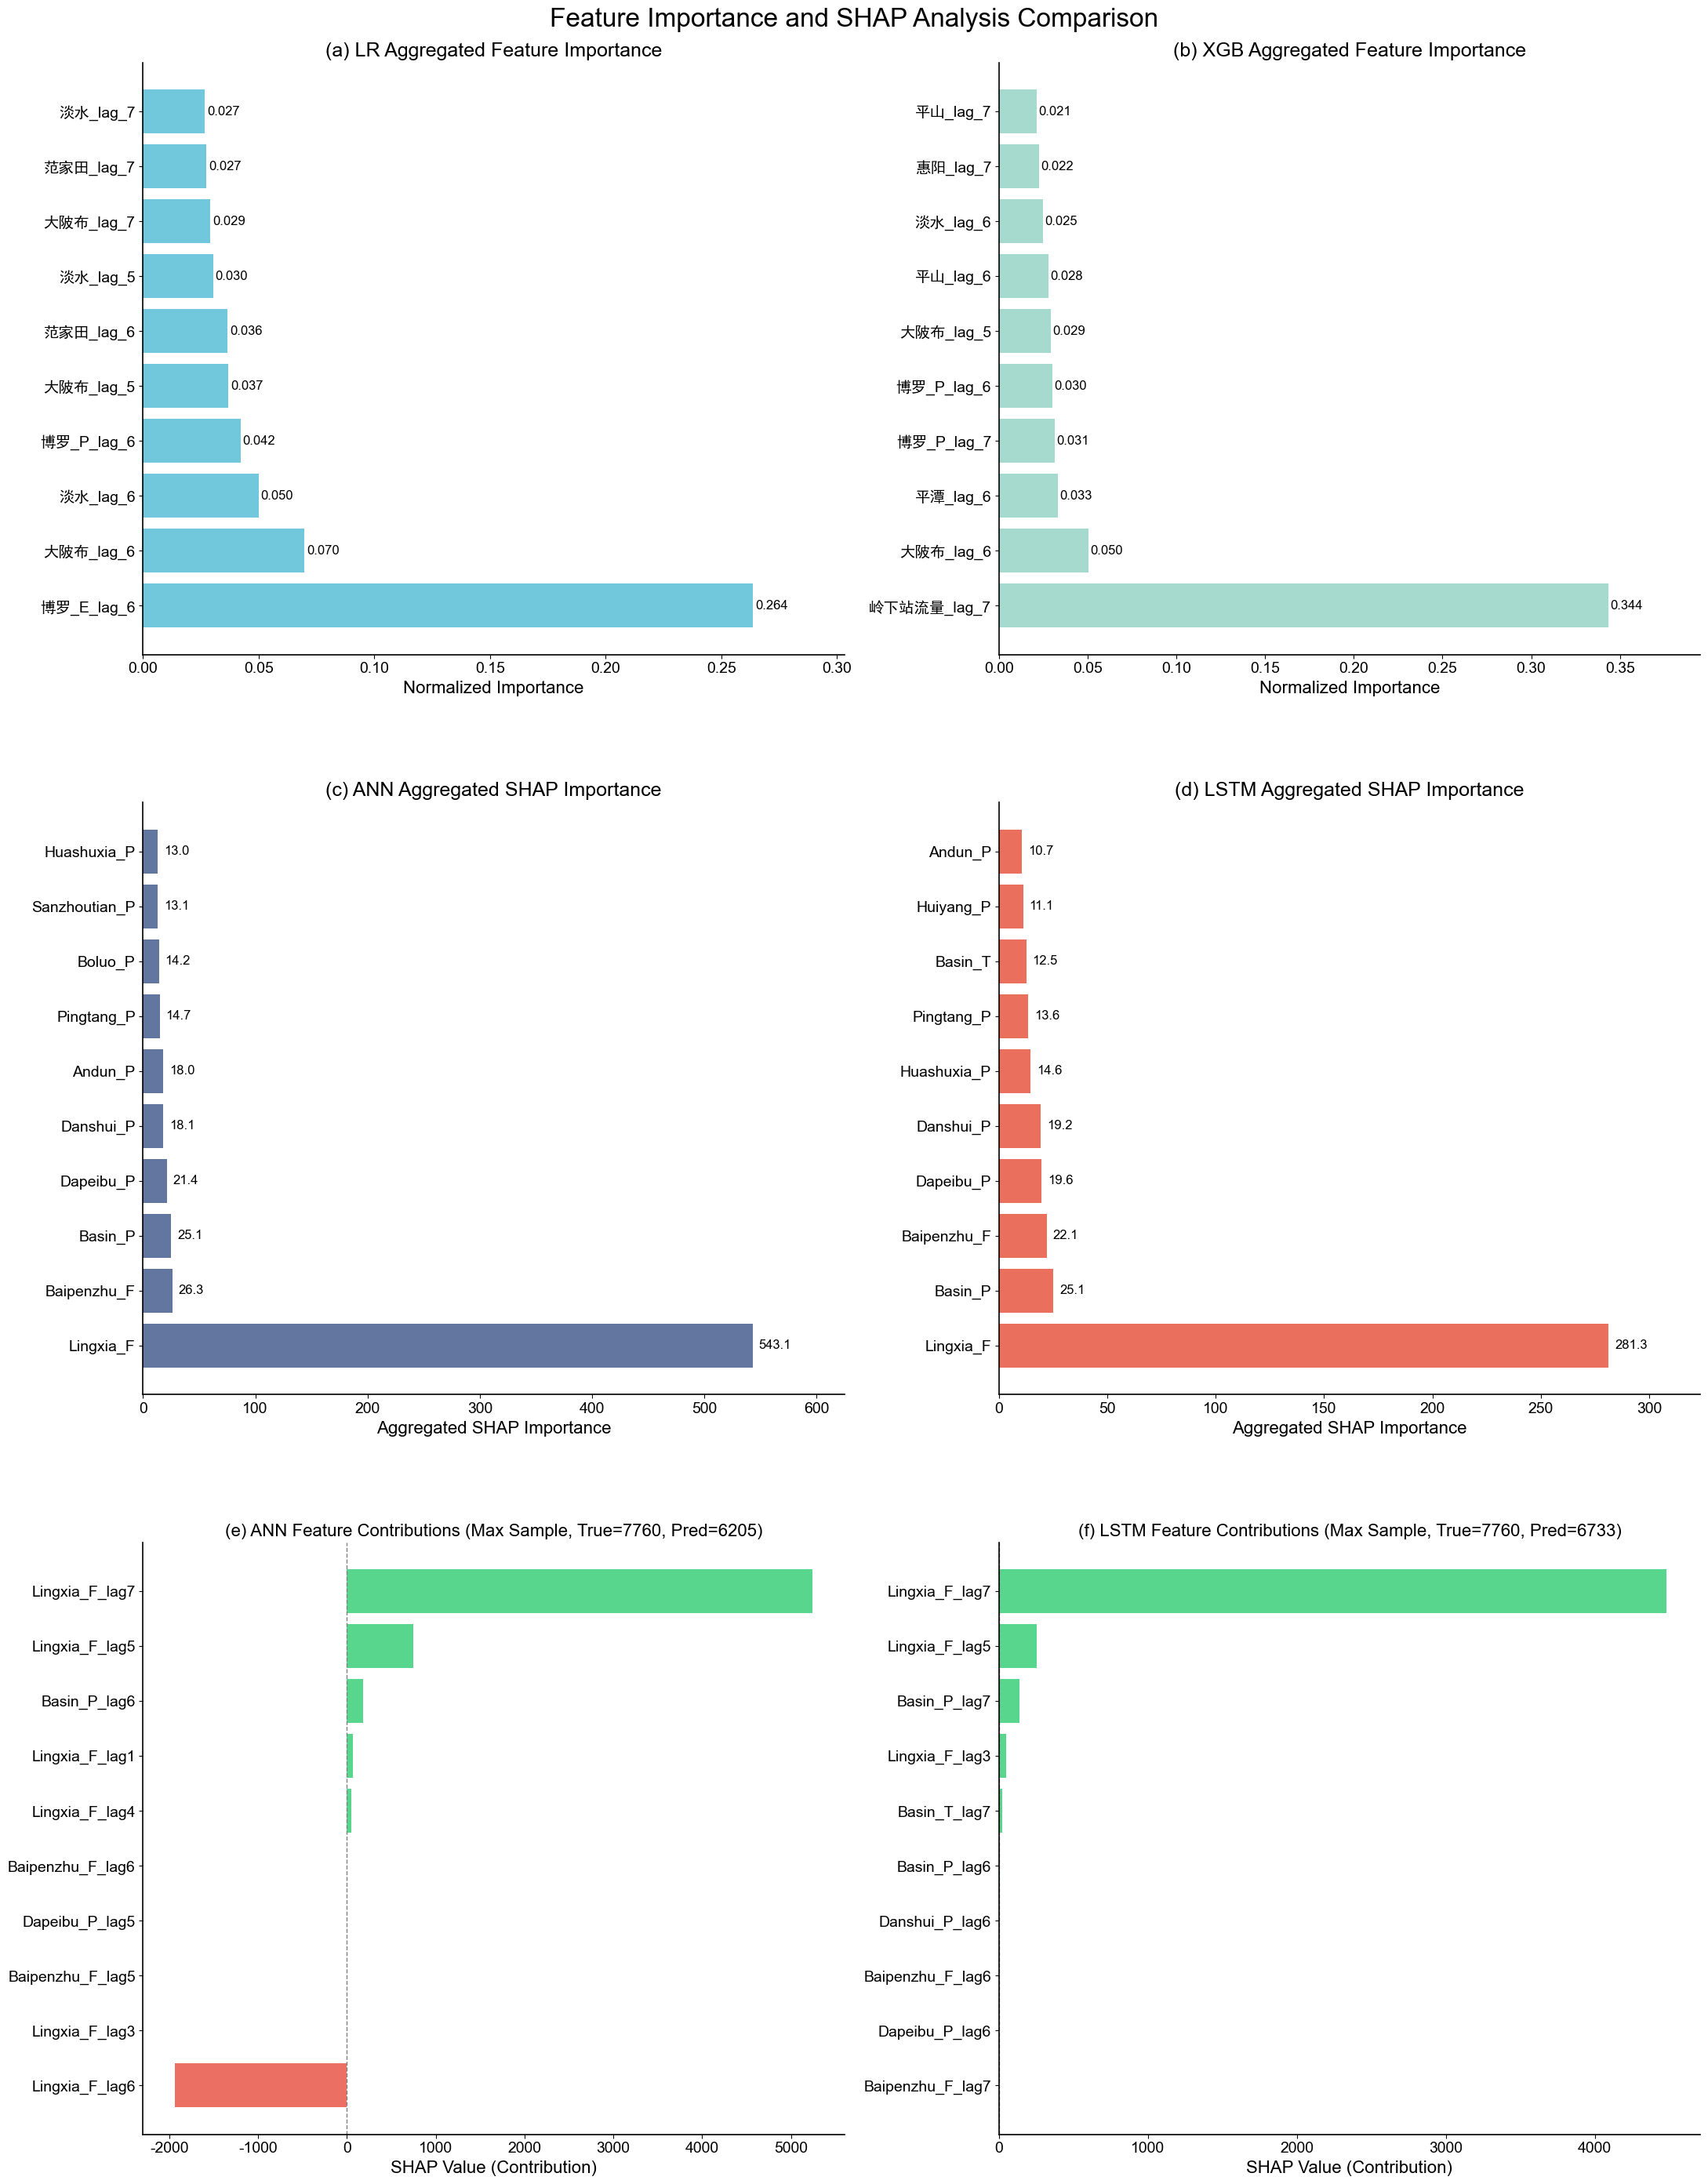

所有模型的特征重要性和SHAP分析已完成！
所有结果已保存至: combined_analysis_results


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import re
import shap
from sklearn.model_selection import train_test_split
from matplotlib.colors import LinearSegmentedColormap

# 设置全局字体和绘图参数（统一设置为较大字号，确保所有子图字体协调）
plt.rcParams["font.family"] = ["Arial", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["lines.linewidth"] = 2.0
plt.rcParams["patch.edgecolor"] = "white"
plt.rcParams["patch.linewidth"] = 0.8

# 模型颜色配置
MODEL_COLORS = {
    "LR": "#33a4cc",
    "XGB": "#c05452",
    "ANN": "#8e44ad"  # 紫色系用于ANN
}

# 特征映射：中文 -> 英文
FEATURE_MAPPING = {
    # 流量站点
    '岭下站流量': 'Lingxia_F',
    '白盆珠出库流量': 'Baipenzhu_F',
    
    # 雨量站点
    '大陂布': 'Dapeibu_P',
    '安墩': 'Andun_P',
    '平山': 'Pingshan_P',
    '平潭': 'Pingtang_P',
    '惠阳': 'Huiyang_P',
    '横沥': 'Hengli_P',
    '洋潭': 'Yangtan_P',
    '淡水': 'Danshui_P',
    '清林径': 'Qinglinjing_P',
    '花树下': 'Huashuxia_P',
    '范家田': 'Fanjiatian_P',
    '上坪': 'Shangping_P',
    '三洲田': 'Sanzhoutian_P',
    
    # 博罗站的各种指标
    '博罗': 'Boluo_P',
    '博罗_T': 'Basin_T',
    '博罗_P': 'Basin_P',
    '博罗_E': 'Basin_E'
}

# ------------------------------
# 数据和模型加载函数
# ------------------------------
def load_all_data_and_models(train_path='../数据/train_data.csv', test_path='../数据/test_data.csv', model_dir='./models/'):
    """加载所有数据和模型（LR、XGB和ANN）"""
    # 加载数据
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)
    
    # 从测试集中找出最大径流量样本
    test_flow = test_data['博罗站流量']
    max_test_flow_idx = test_flow.idxmax()
    max_test_flow_value = test_flow[max_test_flow_idx]
    print(f"测试集最大径流量样本索引: {max_test_flow_idx}, 流量值: {max_test_flow_value}")
    
    # 分离特征和目标变量
    X_train = train_data.drop(['博罗站流量', 'date'], axis=1, errors='ignore')
    y_train = train_data['博罗站流量']
    X_test = test_data.drop(['博罗站流量', 'date'], axis=1, errors='ignore')
    y_test = test_data['博罗站流量']
    
    # 提取测试集最大样本的特征和真实值
    max_test_sample_features = X_test.iloc[max_test_flow_idx]
    max_test_sample_true_value = y_test[max_test_flow_idx]
    
    # 划分样本集用于SHAP分析
    X_sample, _, _, _ = train_test_split(
        X_train, y_train, 
        test_size=0.9,  # 仅使用10%的训练数据
        random_state=42,
        stratify=None
    )
    
    # 加载所有模型
    lr_model = joblib.load(os.path.join(model_dir, 'LR_best_model.pkl'))
    xgb_model = joblib.load(os.path.join(model_dir, 'XGB_best_model.pkl'))
    ann_model = joblib.load(os.path.join(model_dir, 'ANN_best_model.pkl'))
    
    # 计算ANN对最大样本的预测值
    max_test_sample_pred_value = ann_model.predict(
        max_test_sample_features.values.reshape(1, -1)
    )[0]
    print(f"测试集最大径流量样本ANN预测值: {max_test_sample_pred_value}")
    
    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_sample': X_sample,
        'feature_names': X_train.columns.tolist(),
        'models': {
            'LR': lr_model,
            'XGB': xgb_model,
            'ANN': ann_model
        },
        # 测试集最大径流样本信息
        'max_test_flow_idx': max_test_flow_idx,
        'max_test_flow_value': max_test_flow_value,
        'max_test_sample_pred_value': max_test_sample_pred_value,
        'max_test_sample_features': max_test_sample_features
    }

# ------------------------------
# 特征名称处理函数
# ------------------------------
def extract_base_feature(feature_name):
    """从带lag的特征名中提取基础特征名"""
    return re.sub(r'_?lag_?\d+$', '', feature_name)

def translate_feature_name(feature):
    """将单个中文特征名翻译为英文"""
    base_feature = extract_base_feature(feature)
    
    if base_feature in FEATURE_MAPPING:
        english_base = FEATURE_MAPPING[base_feature]
        lag_match = re.search(r'_?lag_?(\d+)', feature)
        if lag_match:
            return f"{english_base}_lag{lag_match.group(1)}"
        else:
            return english_base
    return feature

def translate_feature_names(features):
    """将中文特征名列表翻译为英文"""
    return [translate_feature_name(f) for f in features]

# ------------------------------
# 特征重要性计算函数
# ------------------------------
def calculate_feature_importance(data):
    """计算LR和XGB两种模型的特征重要性"""
    feature_names = data['feature_names']
    models = data['models']
    
    importance_results = {}
    
    # 1. 线性回归 (LR) - 使用系数绝对值作为重要性
    lr_importance = np.abs(models['LR'].coef_)
    importance_results['LR'] = pd.DataFrame({
        'feature': feature_names,
        'importance': lr_importance / np.sum(lr_importance)  # 归一化
    }).sort_values('importance', ascending=False)
    
    # 2. XGBoost (XGB) - 使用内置特征重要性
    print("正在计算XGB的特征重要性...")
    xgb_importance = models['XGB'].feature_importances_
    importance_results['XGB'] = pd.DataFrame({
        'feature': feature_names,
        'importance': xgb_importance / np.sum(xgb_importance)  # 归一化
    }).sort_values('importance', ascending=False)
    
    return importance_results

def aggregate_lag_importance(importance_df):
    """将相同基础特征不同lag天数的重要性合并"""
    importance_df['base_feature'] = importance_df['feature'].apply(extract_base_feature)
    aggregated_df = importance_df.groupby('base_feature')['importance'].sum().reset_index()
    aggregated_df['base_feature_english'] = translate_feature_names(aggregated_df['base_feature'])
    aggregated_df['importance'] = aggregated_df['importance'] / aggregated_df['importance'].sum()
    return aggregated_df.sort_values('importance', ascending=False)

# ------------------------------
# SHAP分析函数
# ------------------------------
def calculate_shap_values(data, use_gpu=False, save_path=None):
    """计算ANN模型的SHAP值并可选保存结果"""
    model = data['models']['ANN']
    X_sample = data['X_sample']
    feature_names = data['feature_names']
    
    # 转换特征名为英文
    english_features = translate_feature_names(feature_names)
    X_sample.columns = english_features
    
    print("初始化SHAP解释器...")
    if hasattr(model, 'predict_proba'):
        explainer = shap.KernelExplainer(
            lambda x: model.predict_proba(x)[:, 1], 
            X_sample.sample(min(100, len(X_sample)), random_state=42)
        )
    else:
        explainer = shap.KernelExplainer(
            model.predict, 
            X_sample.sample(min(100, len(X_sample)), random_state=42)
        )
    
    print("计算SHAP值（这可能需要几分钟时间）...")
    # 计算所有测试样本的SHAP值
    X_test_english = data['X_test'].copy()
    X_test_english.columns = english_features
    shap_values = explainer.shap_values(
        X_test_english,
        nsamples=200,
        l1_reg="auto",
        use_gpu=use_gpu
    )
    
    # 只保存必要的数据
    results = {
        'shap_values': shap_values,
        'X_test': X_test_english,
        'feature_names': english_features,
        'expected_value': explainer.expected_value
    }
    
    # 保存计算结果
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        if os.path.exists(save_path):
            try:
                os.remove(save_path)
            except:
                pass
        joblib.dump(results, save_path)
        print(f"SHAP计算结果已保存至: {save_path}")
    
    return results

def load_shap_results(load_path):
    """加载已保存的SHAP计算结果，增加错误处理"""
    if not os.path.exists(load_path):
        return None
        
    if os.path.getsize(load_path) < 1024:  # 小于1KB的文件视为无效
        print(f"检测到可能损坏的SHAP结果文件: {load_path}")
        return None
        
    try:
        print(f"加载已保存的SHAP结果: {load_path}")
        return joblib.load(load_path)
    except (EOFError, pickle.UnpicklingError, Exception) as e:
        print(f"加载SHAP结果失败: {str(e)}")
        print("将重新计算SHAP值...")
        try:
            os.remove(load_path)
        except:
            pass
        return None

def analyze_shap_importance(shap_results, output_dir='ann_shap_results'):
    """分析SHAP特征重要性并保存结果"""
    os.makedirs(output_dir, exist_ok=True)
    
    # 计算特征重要性（SHAP值的绝对值平均值）
    feature_importance = np.mean(np.abs(shap_results['shap_values']), axis=0)
    
    # 创建重要性DataFrame
    importance_df = pd.DataFrame({
        'feature': shap_results['feature_names'],
        'shap_importance': feature_importance
    }).sort_values('shap_importance', ascending=False)
    
    # 保存原始重要性数据
    importance_df.to_csv(os.path.join(output_dir, 'shap_feature_importance.csv'), index=False)
    
    # 聚合滞后特征的重要性
    importance_df['base_feature'] = importance_df['feature'].apply(
        lambda x: re.sub(r'_lag\d+$', '', x)
    )
    aggregated_importance = importance_df.groupby('base_feature')['shap_importance'].sum().reset_index()
    aggregated_importance = aggregated_importance.sort_values('shap_importance', ascending=False)
    
    # 保存聚合后的重要性数据
    aggregated_importance.to_csv(os.path.join(output_dir, 'shap_aggregated_importance.csv'), index=False)
    
    return {
        'raw_importance': importance_df,
        'aggregated_importance': aggregated_importance
    }

# ------------------------------
# 主绘图函数 - 2x2组合图
# ------------------------------
def plot_2x2_combined(data, importance_results, shap_results, shap_importance, 
                     output_dir='combined_plots', top_n=10):
    """生成2x2组合图：LR特征重要性、XGB特征重要性、ANN聚合SHAP重要性、ANN最大样本贡献"""
    os.makedirs(output_dir, exist_ok=True)
    
    # 提取所需数据
    ann_color = MODEL_COLORS["ANN"]
    max_test_idx = data['max_test_flow_idx']
    max_test_true_value = data['max_test_flow_value']
    max_test_pred_value = data['max_test_sample_pred_value']
    
    # SHAP相关数据
    shap_values = shap_results['shap_values']
    feature_names = shap_results['feature_names']
    expected_value = shap_results['expected_value']
    
    # 获取排序后的特征索引
    sorted_idx = np.argsort(np.mean(np.abs(shap_values), axis=0))[::-1]
    top_features_idx = sorted_idx[:top_n]
    top_features = [feature_names[i] for i in top_features_idx]
    
    # 创建2x2子图
    fig, axes = plt.subplots(2, 2, figsize=(22, 20))
    fig.suptitle('Feature Importance and SHAP Analysis Comparison', fontsize=24, y=0.99)
    
    # ------------------------------
    # 1. 左上：LR特征重要性
    # ------------------------------
    ax1 = axes[0, 0]
    lr_aggregated = aggregate_lag_importance(importance_results['LR']).head(top_n)
    
    y_pos = np.arange(len(lr_aggregated))
    bars = ax1.barh(y_pos, lr_aggregated['importance'][::-1], 
                   color=MODEL_COLORS['LR'], alpha=0.8)
    
    # 添加数值标签
    for bar in bars:
        width = bar.get_width()
        ax1.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=12)
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(lr_aggregated['base_feature_english'][::-1], fontsize=14)
    ax1.set_xlabel('Normalized Importance', fontsize=16)
    ax1.set_title('(a) LR Aggregated Feature Importance', fontsize=18)
    ax1.invert_yaxis()
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_xlim(0, max(lr_aggregated['importance']) * 1.1)
    
    # ------------------------------
    # 2. 右上：XGB特征重要性
    # ------------------------------
    ax2 = axes[0, 1]
    xgb_aggregated = aggregate_lag_importance(importance_results['XGB']).head(top_n)
    
    y_pos = np.arange(len(xgb_aggregated))
    bars = ax2.barh(y_pos, xgb_aggregated['importance'][::-1], 
                   color=MODEL_COLORS['XGB'], alpha=0.8)
    
    # 添加数值标签
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=12)
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(xgb_aggregated['base_feature_english'][::-1], fontsize=14)
    ax2.set_xlabel('Normalized Importance', fontsize=16)
    ax2.set_title('(b) XGB Aggregated Feature Importance', fontsize=18)
    ax2.invert_yaxis()
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_xlim(0, max(xgb_aggregated['importance']) * 1.1)
    
    # ------------------------------
    # 3. 左下：ANN聚合SHAP重要性
    # ------------------------------
    ax3 = axes[1, 0]
    ann_aggregated = shap_importance['aggregated_importance'].head(top_n)
    
    y_pos = np.arange(len(ann_aggregated))
    ax3.barh(y_pos, ann_aggregated['shap_importance'][::-1], 
            color=ann_color, alpha=0.8)
    
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(ann_aggregated['base_feature'][::-1], fontsize=14)
    ax3.set_xlabel('Aggregated SHAP Importance', fontsize=16)
    ax3.set_title('(c) ANN Aggregated SHAP Importance', fontsize=18)
    ax3.invert_yaxis()
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    
    # ------------------------------
    # 4. 右下：ANN最大样本贡献图
    # ------------------------------
    ax4 = axes[1, 1]
    # 使用测试集最大径流量样本
    sample_shap = shap_values[max_test_idx, top_features_idx]
    
    # 排序特征影响
    sorted_idx = np.argsort(sample_shap)
    sorted_shap = sample_shap[sorted_idx]
    sorted_features = [top_features[i] for i in sorted_idx]
    
    # 绘制水平条形图
    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in sorted_shap]
    ax4.barh(range(len(sorted_shap)), sorted_shap, color=colors, alpha=0.8)
    
    # 添加基准线、预测值和真实值
    ax4.axvline(x=expected_value, color='gray', linestyle='--', label='Base Value')
    ax4.axvline(x=max_test_pred_value, color='blue', linestyle='-', 
               label=f'Predicted: {max_test_pred_value:.2f}')
    ax4.axvline(x=max_test_true_value, color='green', linestyle='-', 
               label=f'True: {max_test_true_value:.2f}')
    
    ax4.set_yticks(range(len(sorted_shap)))
    ax4.set_yticklabels(sorted_features, fontsize=14)
    ax4.set_xlabel('Contribution to Prediction', fontsize=16)
    ax4.set_title(f'(d) ANN Feature Contributions (Max Test Sample {max_test_idx})', fontsize=18)
    ax4.legend(fontsize=14)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    
    # 调整布局
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    
    # 保存图像
    output_path = os.path.join(output_dir, '2x2_combined_feature_analysis.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"2x2组合分析图表已保存至: {output_path}")
    plt.show()
    
    return output_path

# ------------------------------
# 主函数
# ------------------------------
def main():
    # 配置参数
    train_path = '../数据/train_data.csv'
    test_path = '../数据/test_data.csv'
    model_dir = './models/'
    output_root = 'combined_analysis_results'
    shap_save_path = os.path.join(output_root, 'ann_shap_test_results.pkl')
    use_gpu = False
    top_n_features = 10
    
    os.makedirs(output_root, exist_ok=True)
    
    # 加载所有数据和模型
    print("步骤1/5: 加载所有数据和模型...")
    data = load_all_data_and_models(
        train_path=train_path,
        test_path=test_path,
        model_dir=model_dir
    )
    
    # 计算LR和XGB的特征重要性
    print("步骤2/5: 计算LR和XGB的特征重要性...")
    importance_results = calculate_feature_importance(data)
    
    # 处理ANN的SHAP分析
    print("步骤3/5: 加载或计算ANN的SHAP值...")
    shap_results = load_shap_results(shap_save_path)
    
    if shap_results is None:
        shap_results = calculate_shap_values(
            data, 
            use_gpu=use_gpu,
            save_path=shap_save_path
        )
    else:
        print("已加载SHAP结果，跳过计算步骤")
    
    # 分析SHAP重要性
    print("步骤4/5: 分析SHAP特征重要性...")
    shap_importance = analyze_shap_importance(
        shap_results, 
        output_dir=os.path.join(output_root, 'ann_shap_importance')
    )
    
    # 生成2x2组合图
    print("步骤5/5: 生成2x2组合分析图表...")
    plot_2x2_combined(
        data,
        importance_results,
        shap_results,
        shap_importance,
        output_dir=os.path.join(output_root, 'plots'),
        top_n=top_n_features
    )
    
    print("所有模型的特征重要性和SHAP分析已完成！")
    print(f"所有结果已保存至: {output_root}")
    return importance_results, shap_results, shap_importance

if __name__ == "__main__":
    import pickle
    importance_results, shap_results, shap_importance = main()